In [1]:
## Imports

In [2]:
import scanpy as sc
import numpy as np
import scipy as sp
import os, sys

In [3]:
os.chdir('../../data')

In [4]:
sys.path.append('../src')
from utils import cell_cycle_markers, cell_type_markers
## Load data
g6 = sc.read_h5ad('egfDuod_G6_DZ.h5ad')
## Identify our normalised and raw matrices

In [5]:
adata = g6

In [6]:
sc.settings.figdir = "/Users/stanleydale/user_generated/breault-lab/single-cell/figures"

In [7]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30)
sc.tl.leiden(adata, resolution=2, n_iterations = -1)
sc.tl.umap(adata)


/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/opt/anaconda3/envs/single-cell-env/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/gs/k55rgtm50g938k87mvcdclqr0000gq/T/ipykernel_4033/3867236213.py:8: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=2,

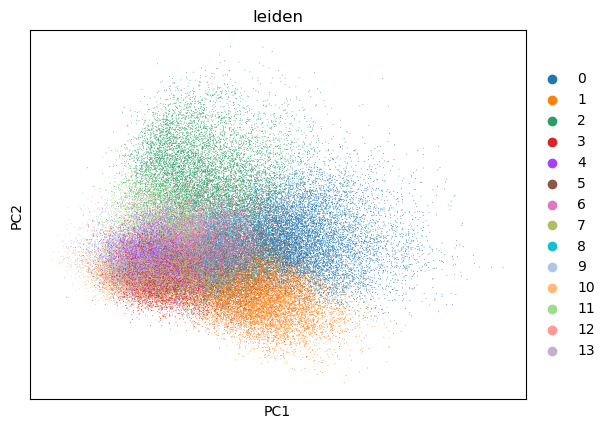

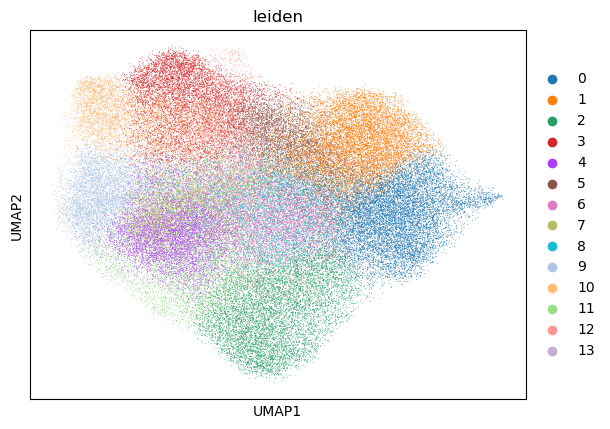

In [8]:
sc.pl.pca(adata, color="leiden")
sc.pl.umap(adata, color="leiden")


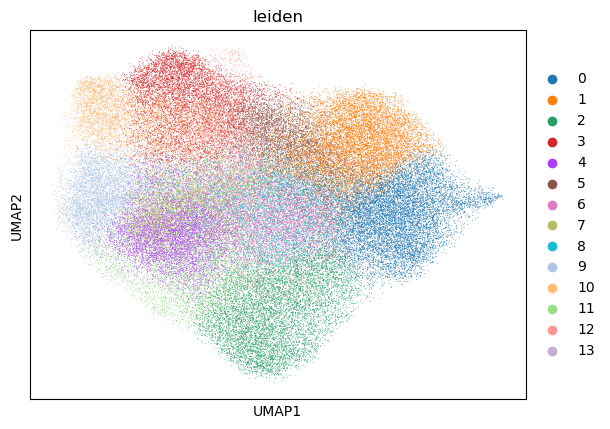

In [ ]:
sc.pl.umap(adata, color="leiden", save="_g6_clustered.pdf")


In [10]:
#### This is much better
g6.obsm['X_pca'] = adata.obsm['X_pca']
g6.obsm['X_umap'] = adata.obsm['X_umap']
g6

g6.obs['leiden'] = adata.obs['leiden'].astype('category')
g6.obsp['distances'] = adata.obsp['distances']
g6.obsp['connectivities'] = adata.obsp['connectivities']

In [11]:
## Save our clustered data

intermediate_directory = '/Users/stanleydale/user_generated/breault-lab/single-cell/analysis'
sc.write(f'{intermediate_directory}/clustered_egfDuod_G6_DZ.h5ad', g6)